In [1]:
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import useful_rdkit_utils as uru
from rdkit import DataStructs
from tqdm.auto import tqdm
from lightgbm import LGBMRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

/home/rohankhopkar/micromamba/envs/smolmolfinal/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
I0000 00:00:1775498745.230122   62552 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1775498745.308744   62552 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1775498746.235203   62552 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results 

In [2]:
tqdm.pandas()
sns.set_style("whitegrid")
sns.set_context("notebook")

In [4]:
train_df         = pd.read_csv("hf://datasets/openadmet/pxr-challenge-train-test/pxr-challenge_TRAIN.csv") # 4140 molecules that passed the single concentration test?
test_df          = pd.read_csv("hf://datasets/openadmet/pxr-challenge-train-test/pxr-challenge_TEST_BLINDED.csv") # 513 (63 + analog) final filtered molecules with high pEC50 AND counter assay success?
train_counter_df = pd.read_csv("hf://datasets/openadmet/pxr-challenge-train-test/pxr-challenge_counter-assay_TRAIN.csv") # Molecules that passed the counter assay test from the original train set?
train_single_df  = pd.read_csv("hf://datasets/openadmet/pxr-challenge-train-test/pxr-challenge_single_concentration_TRAIN.csv") # All of the molecules used in the single concentration test, regardless of if there was PXR reaction.

In [5]:
# Select the relevant columns
keep_cols = [
    "Molecule Name", "SMILES", "pEC50",
    "pEC50_std.error (-log10(molarity))",
    "pEC50_ci.lower (-log10(molarity))",
    "pEC50_ci.upper (-log10(molarity))",
    "Emax_estimate (log2FC vs. baseline)",
    "Emax.vs.pos.ctrl_estimate (dimensionless)",
    "Split",
]
model_df = train_df[keep_cols].copy()

# Use shorter column names for convenience
model_df = model_df.rename(columns={
    "pEC50_std.error (-log10(molarity))": "pEC50_std_error",
    "pEC50_ci.lower (-log10(molarity))":  "pEC50_ci_lower",
    "pEC50_ci.upper (-log10(molarity))":  "pEC50_ci_upper",
    "Emax_estimate (log2FC vs. baseline)":         "Emax",
    "Emax.vs.pos.ctrl_estimate (dimensionless)":   "Emax_vs_ctrl",
})
model_df.head()

,Molecule Name,SMILES,pEC50,pEC50_std_error,pEC50_ci_lower,pEC50_ci_upper,Emax,Emax_vs_ctrl,Split
0,OADMET-0006089,CC1C2CCCCC2CN1C(=O)C1=CC(F)=CC2=C1CNCC2,5.27,0.0620,5.13,5.38,1.67,0.539,Train
1,OADMET-0006088,CN(C(=O)C1=CC=CC=C1SCC(=O)N1CCC2=CC=CC=C21)C1C...,5.08,0.0870,4.89,5.22,1.70,0.491,Train
2,OADMET-0006087,O=C(C1CCCC1)N1CC(S(=O)(=O)NC2CC2C2=C(F)C=CC=C2...,5.12,0.1660,4.79,5.39,1.88,0.663,Train
3,OADMET-0006086,CC1CN(C(=O)C2=CC=CC(C3=C(F)C=CC=C3F)=C2)CCN1C1...,5.23,0.1120,4.99,5.42,2.20,0.889,Train
4,OADMET-0006085,CC1(C2=NOC(C3=NN(CC4=CC=C(F)C=C4)C(=O)CC3)=N2)...,5.28,0.0466,5.18,5.37,1.82,0.623,Train


---

In [6]:
rdkit_desc = uru.RDKitDescriptors()

# Work with the subset that has a valid pEC50 measurement
train_pec50 = model_df.dropna(subset=["pEC50"]).copy()
print(f"Compounds with valid pEC50: {len(train_pec50)}")

train_pec50["descriptors"] = [rdkit_desc.calc_smiles(x) for x in tqdm(train_pec50.SMILES)]

from rdkit.Chem import AllChem
from rdkit import Chem

def get_morgan_fp(smiles, radius=2, nbits=2048):
    mol = Chem.MolFromSmiles(smiles)
    return AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=nbits)

from rdkit.Chem import Descriptors, rdMolDescriptors, AllChem
def get_pxr_specific_features(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if not mol: return np.zeros(10) # Placeholder

    # 1. Aromaticity/Stacking Potential (The Triad Signal)
    # F288/W299/Y306 love large aromatic systems
    n_aromatic_rings = rdMolDescriptors.CalcNumAromaticRings(mol)
    max_ring_size = max([len(r) for r in mol.GetRingInfo().AtomRings()], default=0)

    # 2. Hydrophobic "Bulk" vs Polar "Disruption"
    # Ratio of carbons to heteroatoms (O, N, S)
    n_c = len([a for a in mol.GetAtoms() if a.GetSymbol() == 'C'])
    n_het = rdMolDescriptors.CalcNumHeteroatoms(mol)
    c_het_ratio = n_c / (n_het + 1)

    # 3. Steric "Center of Gravity"
    # Branching (Chi4v) is a good proxy for filling the spherical triad site
    chi4v = rdMolDescriptors.CalcChi4v(mol)

    return [n_aromatic_rings, max_ring_size, c_het_ratio, chi4v, n_het]

train_pec50["morgan_fp"] = train_pec50["SMILES"].apply(get_morgan_fp)
train_pec50["pxr_extra_feats"] = train_pec50["SMILES"].apply(get_pxr_specific_features)

# Concatenate with existing descriptors
X = np.hstack([
    np.stack(train_pec50.descriptors),
    np.stack(train_pec50.morgan_fp),
    np.stack(train_pec50.pxr_extra_feats)
])


from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold
from collections import defaultdict
import numpy as np

def scaffold_split(df, test_size=0.25, smiles_col="SMILES", seed=42):
    """Split a dataframe by Bemis-Murcko scaffold."""
    # Get scaffold for each molecule
    scaffolds = defaultdict(list)
    for idx, row in df.iterrows():
        mol = Chem.MolFromSmiles(row[smiles_col])
        scaffold = MurckoScaffold.MurckoScaffoldSmiles(mol=mol, includeChirality=False)
        scaffolds[scaffold].append(idx)

    # Shuffle scaffold groups
    scaffold_groups = list(scaffolds.values())
    rng = np.random.default_rng(seed)
    rng.shuffle(scaffold_groups)

    # Fill test set up to test_size
    n_test_target = int(len(df) * test_size)
    train_idx, test_idx = [], []
    for group in scaffold_groups:
        if len(test_idx) < n_test_target:
            test_idx.extend(group)
        else:
            train_idx.extend(group)

    return df.loc[train_idx], df.loc[test_idx]

result_list = []
for i in tqdm(range(7)):
    train, test = scaffold_split(train_pec50, smiles_col="SMILES", seed=i)

    X_train = np.hstack([np.stack(train.descriptors), np.stack(train.morgan_fp), np.stack(train.pxr_extra_feats)])
    X_test = np.hstack([np.stack(test.descriptors), np.stack(test.morgan_fp), np.stack(test.pxr_extra_feats)])

    lgbm = LGBMRegressor(
        n_estimators=1000,       # Increase from default
        learning_rate=0.03,      # Slower learning is better for cliffs
        num_leaves=63,           # Allow more complex trees
        min_child_samples=10,     # Good for small datasets
        random_state=42
    )
    # weights = 1 / train["pEC50_std_error"].clip(lower=0.01)

    # lgbm.fit(X_train, train["pEC50"], sample_weight=weights)
    lgbm.fit(np.stack(X_train), train["pEC50"])

    with warnings.catch_warnings():
        warnings.simplefilter("ignore", UserWarning)
        pred = lgbm.predict(X_test)

    r2 = r2_score(test["pEC50"], pred)
    result_list.append([len(train), len(test), r2])

result_df = pd.DataFrame(result_list, columns=["Num_Train", "Num_Test", "R2"])
result_df

Compounds with valid pEC50: 4140


100%|██████████| 4140/4140 [00:16<00:00, 248.67it/s]
[13:08:45] DEPRECATION WARNING: please use MorganGenerator
[13:08:45] DEPRECATION WARNING: please use MorganGenerator
[13:08:45] DEPRECATION WARNING: please use MorganGenerator
[13:08:45] DEPRECATION WARNING: please use MorganGenerator
[13:08:45] DEPRECATION WARNING: please use MorganGenerator
[13:08:45] DEPRECATION WARNING: please use MorganGenerator
[13:08:45] DEPRECATION WARNING: please use MorganGenerator
[13:08:45] DEPRECATION WARNING: please use MorganGenerator
[13:08:45] DEPRECATION WARNING: please use MorganGenerator
[13:08:45] DEPRECATION WARNING: please use MorganGenerator
[13:08:45] DEPRECATION WARNING: please use MorganGenerator
[13:08:45] DEPRECATION WARNING: please use MorganGenerator
[13:08:45] DEPRECATION WARNING: please use MorganGenerator
[13:08:45] DEPRECATION WARNING: please use MorganGenerator
[13:08:45] DEPRECATION WARNING: please use MorganGenerator
[13:08:45] DEPRECATION WARNING: please use MorganGenerator
[13

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.012535 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 26890
[LightGBM] [Info] Number of data points in the train set: 3105, number of used features: 2044
[LightGBM] [Info] Start training from score 4.299899


 14%|█▍        | 1/7 [00:07<00:45,  7.50s/it]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.012231 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 26984
[LightGBM] [Info] Number of data points in the train set: 3105, number of used features: 2060
[LightGBM] [Info] Start training from score 4.375410


...

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009327 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 26936
[LightGBM] [Info] Number of data points in the train set: 3105, number of used features: 2060
[LightGBM] [Info] Start training from score 4.389934


 86%|████████▌ | 6/7 [00:48<00:07,  7.97s/it]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009940 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 26900
[LightGBM] [Info] Number of data points in the train set: 3105, number of used features: 2038
[LightGBM] [Info] Start training from score 4.303524


100%|██████████| 7/7 [00:56<00:00,  8.08s/it]


,Num_Train,Num_Test,R2
0,3105,1035,0.556015
1,3105,1035,0.633820
2,3105,1035,0.619688
3,3104,1036,0.596159
4,3105,1035,0.547097
5,3105,1035,0.693995
6,3105,1035,0.548979


---

In [7]:
from rdkit.Chem.Scaffolds import MurckoScaffold

def add_scaffold_context_features(df):
    # 1. Generate Murcko Scaffolds for the entire set
    df['scaffold'] = df['SMILES'].apply(lambda x: MurckoScaffold.MurckoScaffoldSmiles(
        mol=Chem.MolFromSmiles(x), includeChirality=False))

    # 2. Calculate average properties per scaffold family
    # We focus on the "Inflation" and "Polarity" drivers from your charts
    scaffold_stats = df.groupby('scaffold').agg({
        'MolWt': 'mean',
        'BertzCT': 'mean',
        'NumHeteroatoms': 'mean',
        'PEOE_VSA4': 'mean'
    }).rename(columns={
        'MolWt': 'avg_scaff_wt',
        'BertzCT': 'avg_scaff_complex',
        'NumHeteroatoms': 'avg_scaff_polar',
        'PEOE_VSA4': 'avg_scaff_vsa'
    })

    df = df.merge(scaffold_stats, on='scaffold', how='left')

    # 3. Create the "Delta" features (The Activity Cliff Triggers)
    df['delta_wt'] = df['MolWt'] - df['avg_scaff_wt']
    df['delta_complexity'] = df['BertzCT'] - df['avg_scaff_complex']
    df['delta_polar_pollution'] = df['NumHeteroatoms'] - df['avg_scaff_polar']

    return df

In [8]:
def get_interaction_features(descriptors_array, morgan_fp_array, top_bit_indices=[1, 42, 128]):
    """
    Multiplies Top Global Descriptors by Top Morgan Bits.
    This helps the model see 'This fragment causes a clash ONLY when the molecule is heavy'.
    """
    interactions = []
    # Index 0 is usually MolWt in your descriptor list
    mol_wt = descriptors_array[:, 0]

    for bit_idx in top_bit_indices:
        bit_col = morgan_fp_array[:, bit_idx]
        # Intersection: High Weight * Specific Fragment Presence
        interactions.append(mol_wt * bit_col)

    return np.column_stack(interactions)

In [9]:
import pandas as pd
import numpy as np
import warnings
from tqdm import tqdm
from rdkit import Chem
from rdkit.Chem import Descriptors, AllChem
from rdkit.Chem.Scaffolds import MurckoScaffold
from lightgbm import LGBMRegressor, early_stopping
from sklearn.metrics import r2_score

# 1. SETUP DATA AND SCALABLE DESCRIPTORS
train_pec50 = model_df.dropna(subset=["pEC50"]).copy()
rdkit_desc = uru.RDKitDescriptors()

print(f"Processing {len(train_pec50)} compounds with valid pEC50...")

# Generate Base Descriptors and Fingerprints
train_pec50["descriptors"] = [rdkit_desc.calc_smiles(x) for x in tqdm(train_pec50.SMILES, desc="RDKit Descs")]
train_pec50["morgan_fp"] = [get_morgan_fp(x) for x in tqdm(train_pec50.SMILES, desc="Morgan FPs")]

# 2. CODIFY STRUCTURAL CONTEXT (SCAFFOLD DELTAS)
# This mimics the "Pocket Inflation" and "Triad Anchor" logic
def add_structural_context(df):
    # Identify the 'Backbone'
    df['scaffold'] = df['SMILES'].apply(lambda x: MurckoScaffold.MurckoScaffoldSmiles(
        mol=Chem.MolFromSmiles(x), includeChirality=False))

    # Calculate family averages for key PXR drivers
    # Note: We use specific indices from the RDKit descriptor list for MolWt, etc.
    # Alternatively, we can just calculate them fresh for the context
    df['temp_molwt'] = df['SMILES'].apply(lambda x: Descriptors.MolWt(Chem.MolFromSmiles(x)))
    df['temp_het'] = df['SMILES'].apply(lambda x: Descriptors.NumHeteroatoms(Chem.MolFromSmiles(x)))

    scaffold_stats = df.groupby('scaffold').agg({
        'temp_molwt': 'mean',
        'temp_het': 'mean'
    }).rename(columns={'temp_molwt': 'avg_scaff_wt', 'temp_het': 'avg_scaff_het'})

    df = df.merge(scaffold_stats, on='scaffold', how='left')

    # Create the "Inflation" and "Polar Pollution" features
    df['delta_wt'] = df['temp_molwt'] - df['avg_scaff_wt']
    df['delta_polar_pollution'] = df['temp_het'] - df['avg_scaff_het']

    return df

train_pec50 = add_structural_context(train_pec50)

# 3. DEFINE FEATURE SETS
# We'll use the base descriptors, the 2048-bit Morgan FP, and our 2 new structural context features
context_cols = ['delta_wt', 'delta_polar_pollution']

# 4. CROSS-VALIDATION TRAINING LOOP
result_list = []
n_iterations = 7

for i in tqdm(range(n_iterations), desc="Cross-Validation Folds"):
    # Split by scaffold to ensure we aren't "leaking" family info into the test set
    train, test = scaffold_split(train_pec50, smiles_col="SMILES", seed=i)

    # Stack Features: [Standard Descs] + [Morgan Bits] + [Structural Context]
    X_train = np.hstack([
        np.stack(train.descriptors),
        np.stack(train.morgan_fp),
        train[context_cols].values
    ])

    X_test = np.hstack([
        np.stack(test.descriptors),
        np.stack(test.morgan_fp),
        test[context_cols].values
    ])

    # 5. TUNED LGBM FOR ACTIVITY CLIFFS
    # We use a lower learning rate and more estimators to find the "Inflation" threshold
    lgbm = LGBMRegressor(
        n_estimators=3000,
        learning_rate=0.02,
        num_leaves=31,
        max_depth=7,
        min_child_samples=15, # Prevents overfitting to a single outlier analogue
        importance_type='gain',
        random_state=i,
        verbose=-1
    )

    # Use early stopping to find the point where the "Inflation" penalty generalizes best
    lgbm.fit(
        X_train, train["pEC50"],
        eval_set=[(X_test, test["pEC50"])],
        eval_metric='rmse',
        callbacks=[early_stopping(stopping_rounds=100)]
    )

    with warnings.catch_warnings():
        warnings.simplefilter("ignore", UserWarning)
        pred = lgbm.predict(X_test)

    r2 = r2_score(test["pEC50"], pred)
    result_list.append([len(train), len(test), r2])

# 6. RESULTS
result_df = pd.DataFrame(result_list, columns=["Num_Train", "Num_Test", "R2"])
print("\n--- Final Performance Summary ---")
print(result_df)
print(f"Mean R2: {result_df.R2.mean():.4f}")

Processing 4140 compounds with valid pEC50...


Morgan FPs:   0%|          | 0/4140 [00:00<?, ?it/s][13:10:02] DEPRECATION WARNING: please use MorganGenerator
[13:10:02] DEPRECATION WARNING: please use MorganGenerator
[13:10:02] DEPRECATION WARNING: please use MorganGenerator
[13:10:02] DEPRECATION WARNING: please use MorganGenerator
[13:10:02] DEPRECATION WARNING: please use MorganGenerator
[13:10:02] DEPRECATION WARNING: please use MorganGenerator
[13:10:02] DEPRECATION WARNING: please use MorganGenerator
[13:10:02] DEPRECATION WARNING: please use MorganGenerator
[13:10:02] DEPRECATION WARNING: please use MorganGenerator
[13:10:02] DEPRECATION WARNING: please use MorganGenerator
[13:10:02] DEPRECATION WARNING: please use MorganGenerator
[13:10:02] DEPRECATION WARNING: please use MorganGenerator
[13:10:02] DEPRECATION WARNING: please use MorganGenerator
[13:10:02] DEPRECATION WARNING: please use MorganGenerator
[13:10:02] DEPRECATION WARNING: please use MorganGenerator
[13:10:02] DEPRECATION WARNING: please use MorganGenerator
[13:

Training until validation scores don't improve for 100 rounds


Cross-Validation Folds:  14%|█▍        | 1/7 [00:04<00:26,  4.40s/it]

Early stopping, best iteration is:
[941]	valid_0's rmse: 0.722701	valid_0's l2: 0.522296
Training until validation scores don't improve for 100 rounds


...

Early stopping, best iteration is:
[545]	valid_0's rmse: 0.699668	valid_0's l2: 0.489535
Training until validation scores don't improve for 100 rounds


Cross-Validation Folds:  86%|████████▌ | 6/7 [00:26<00:04,  4.20s/it]

Early stopping, best iteration is:
[460]	valid_0's rmse: 0.663418	valid_0's l2: 0.440123
Training until validation scores don't improve for 100 rounds


Cross-Validation Folds: 100%|██████████| 7/7 [00:30<00:00,  4.32s/it]

Early stopping, best iteration is:
[745]	valid_0's rmse: 0.72397	valid_0's l2: 0.524132

--- Final Performance Summary ---
   Num_Train  Num_Test        R2
0       3105      1035  0.558994
1       3105      1035  0.643856
2       3105      1035  0.616930
3       3104      1036  0.598114
4       3105      1035  0.551209
5       3105      1035  0.701684
6       3105      1035  0.553811
Mean R2: 0.6035


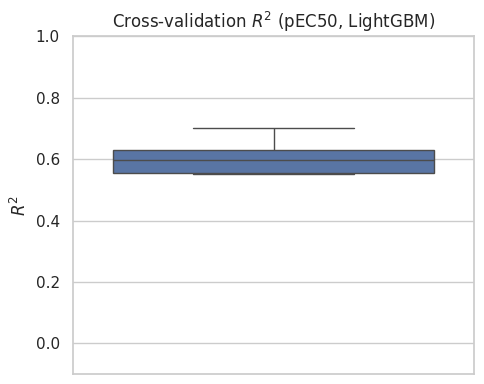

In [10]:
sns.set(rc={"figure.figsize": (5, 4)})
sns.set(style="whitegrid")
ax = sns.boxplot(y="R2", data=result_df)
ax.set_ylim(-0.1, 1)
ax.set_ylabel("$R^2$")
ax.set_title("Cross-validation $R^2$ (pEC50, LightGBM)")
plt.tight_layout()

<Axes: title={'center': 'Top 20 Features for PXR pEC50 Prediction (Scaffold Delta Model)'}>

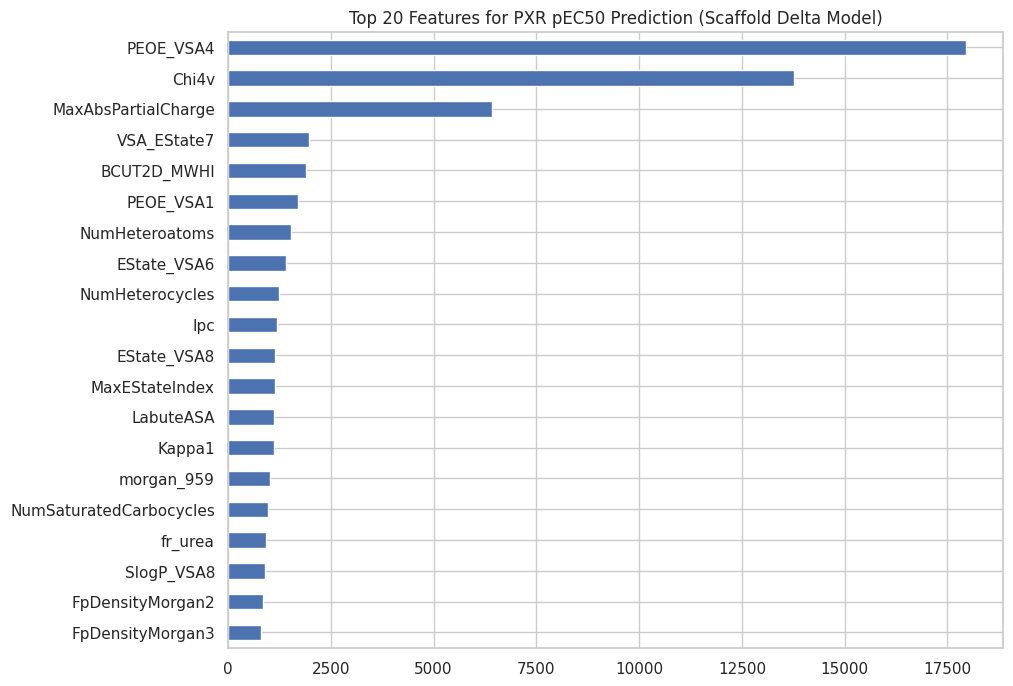

In [11]:
# 1. Get standard RDKit descriptor names
# (This remains the same)
descriptor_names = [x[0] for x in Descriptors._descList]

# 2. Get the Morgan Fingerprint names
# (This remains the same)
morgan_bits = [f"morgan_{i}" for i in range(2048)]

# 3. Use your actual context feature names (from Section 3 of your loop)
# Note: You MUST ensure these are in the same order as in `context_cols`
# and they were concatenated in the hstack operation.
# context_cols = ['delta_wt', 'delta_polar_pollution']
custom_names = ['delta_wt', 'delta_polar_pollution']

# 4. Combine everything in the EXACT order used in your np.hstack
# hstack([np.stack(train.descriptors), np.stack(train.morgan_fp), train[context_cols].values])
feat_names = (
    descriptor_names +
    morgan_bits +
    custom_names
)

# 5. Map to LGBM importances and plot
# Use the last trained LGBM model ('lgbm') and map its importances to your new names
importances = pd.Series(lgbm.feature_importances_, index=feat_names)

# Display the Top 20 for analysis
importances.nlargest(20).sort_values(ascending=True).plot(
    kind="barh",
    figsize=(10, 8),
    title="Top 20 Features for PXR pEC50 Prediction (Scaffold Delta Model)"
)

---

## Submission Results

**Approach:** LGBM with RDKit + Morgan fingerprints + scaffold delta features
**CV RAE:** 0.5735 ± 0.0408 (from 7-fold scaffold CV)
**Blind Test RAE:** 0.679

**Analysis:**
- Good CV performance but didn't translate fully to test set
- CV-to-test gap suggests possible distribution shift
- Scaffold delta features helped in CV but may have overfit

**Key learnings:**
- LGBM baseline is strong (0.679 RAE)
- Need to be careful about CV split representativeness
- Activity cliffs still challenging to capture